<a href="https://colab.research.google.com/github/krishnakumari200424/krishnakumari200424/blob/main/ex2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import io
from google.colab import files

# Step 1: Upload the ZIP file
uploaded = files.upload()

# Step 2: Unzip the uploaded file
for file_name in uploaded.keys():
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(uploaded[file_name]), 'r') as zip_ref:
            zip_ref.extractall()
            print(f"✅ Unzipped '{file_name}' successfully.")

Saving age_detection_dataset (1).zip to age_detection_dataset (1).zip
✅ Unzipped 'age_detection_dataset (1).zip' successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer
from PIL import Image
import imageio

In [ ]:
import os
print(os.listdir())

['.config', 'age_detection_dataset (1).zip', 'drive', 'sample_data', 'age_detection_dataset']


In [ ]:
import os
print(os.listdir('age_detection_dataset'))

['age_detection_test', 'age_detection_train']


In [ ]:
train=pd.read_csv('age_detection_dataset/age_detection_train/train.csv')
test=pd.read_csv('age_detection_dataset/age_detection_test/test.csv')

Age group: MIDDLE


/tmp/ipython-input-10-2398151315.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


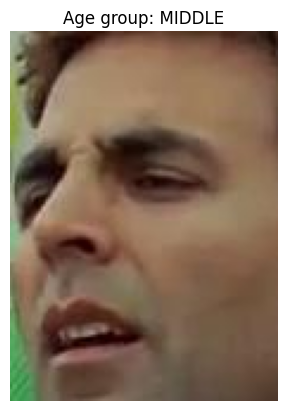

In [ ]:
np.random.seed(10)
idx = np.random.choice(train.index)
img_name = train.ID[idx].strip()
age_group = train.Class[idx]
img_path = os.path.join('age_detection_dataset', 'age_detection_train', 'train', '251.jpg')
if os.path.exists(img_path):
    img = imageio.imread(img_path)
    img = img.astype('uint8')
    print('Age group:', age_group)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Age group: {age_group}")
    plt.show()
else:
    print("❌ File not found:", img_path)

In [ ]:
train_x = []
for img_name in train.ID:
    img_name = img_name.strip()
    img_path = os.path.join('age_detection_dataset', 'age_detection_train', 'train', img_name)
    if os.path.exists(img_path):
        img = imageio.imread(img_path)
        img = Image.fromarray(img).resize((32, 32))
        img = np.array(img).astype('float32')
        train_x.append(img)
    else:
        print(" Missing image:", img_path)

train_x = np.stack(train_x)
print(" Training images shape:", train_x.shape)


/tmp/ipython-input-11-3974775939.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


 Training images shape: (19906, 32, 32, 3)


In [ ]:
test_x = []

for img_name in test.ID:
    img_name = img_name.strip()
    img_path = os.path.join('age_detection_dataset', 'age_detection_test', 'Test', img_name)

    if os.path.exists(img_path):
        img = imageio.imread(img_path)
        img = Image.fromarray(img).resize((32, 32))
        img = np.array(img).astype('float32')
        test_x.append(img)
    else:
        print("❌ Missing test image:", img_path)

test_x = np.stack(test_x)
print(" Test images shape:", test_x.shape)

/tmp/ipython-input-12-4288033098.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


 Test images shape: (6636, 32, 32, 3)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
lb = LabelEncoder()
train_y = lb.fit_transform(train.Class)
train_y = to_categorical(train_y)

print(" Encoded labels shape:", train_y.shape)
print("Classes:", lb.classes_)

 Encoded labels shape: (19906, 3)
Classes: ['MIDDLE' 'OLD' 'YOUNG']


In [ ]:
input_num_units = (32, 32, 3)
output_num_units = 3
epochs = 5
batch_size = 128

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, InputLayer

# Define layer parameters
input_num_units = (32, 32, 3)
hidden_num_units = 128
output_num_units = 3

# Build the model
model = Sequential([
    InputLayer(shape=input_num_units),
    Flatten(),
    Dense(units=hidden_num_units, activation='relu'),
    Dense(units=output_num_units, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='sgd',                      # Stochastic Gradient Descent
    loss='categorical_crossentropy',      # Use this for multi-class classification
    metrics=['accuracy']                  # Track accuracy during training
)

In [ ]:
model.fit(
    train_x,                              # Training image data (normalized)
    train_y,                              # One-hot encoded labels
    batch_size=batch_size,                # Number of samples per gradient update
    epochs=epochs,                        # Total number of training cycles
    verbose=1                             # Show progress
)


Epoch 1/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5236 - loss: 273087.0938
Epoch 2/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5421 - loss: 1.0034
Epoch 3/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5379 - loss: 0.9797
Epoch 4/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5440 - loss: 0.9630
Epoch 5/5
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5341 - loss: 0.9670


In [ ]:
test_preds = model.predict(test_x)
pred_classes = np.argmax(test_preds, axis=1)
pred_labels = lb.inverse_transform(pred_classes)
test['Class'] = pred_labels
test.to_csv('out.csv', index=False)
print("✅ Predictions saved to out.csv")


208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ Predictions saved to out.csv


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/tmp/ipython-input-19-3494456315.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(img_path)


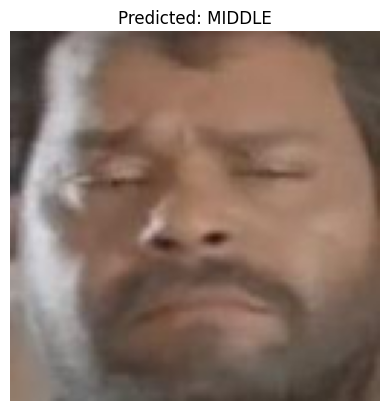

In [ ]:
idx = 2481
img_name = test.ID[idx].strip()
img_path = os.path.join('age_detection_dataset', 'age_detection_test', 'Test', '2.jpg')

img = imageio.imread(img_path)
resized_img = Image.fromarray(img).resize((128, 128))

plt.imshow(resized_img)
plt.axis('off')

pred_probs = model.predict(np.expand_dims(test_x[idx], axis=0))  # shape (1, 32, 32, 3)
pred_label = lb.inverse_transform([np.argmax(pred_probs)])

plt.title(f"Predicted: {pred_label[0]}")
plt.show()